### Random Forest Feature Importance Plot

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
model = joblib.load("../models/trained/model.pkl")

d:\Data science\Python\Elite\Projects\Enterprise customer risk prediction\venv311\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Data science\Python\Elite\Projects\Enterprise customer risk prediction\venv311\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Data science\Python\Elite\Projects\Enterprise customer risk prediction\venv311\Lib\site-packages\s

In [4]:
print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Latitude', 'Longitude',
                                                   'Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges', 'CLTV']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
    

In [6]:
print(model.named_steps.keys())

dict_keys(['preprocessor', 'classifier'])


In [ ]:
# Step 1: Get the Random Forest model

rf = model.named_steps['classifier']
print(type(rf))
print(rf.feature_importances_)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
[0.06746089 0.06722137 0.09293552 0.07578044 0.09046277 0.07136338
 0.01090652 0.01085618 0.00772654 0.00754726 0.0100369  0.0102575
 0.02540876 0.02710534 0.00250869 0.00260994 0.00852643 0.00249687
 0.00819843 0.00870295 0.02843817 0.00259215 0.03567241 0.0042527
 0.00943081 0.01271777 0.00361905 0.00828008 0.00871556 0.00312551
 0.00710739 0.02870845 0.00243885 0.00829329 0.00741807 0.00291447
 0.00739777 0.00724991 0.00318965 0.00788433 0.08302592 0.01090253
 0.03279348 0.01008201 0.00966686 0.00871357 0.0082977  0.02168525
 0.00727361]


In [10]:
# Step 2: Get feature names after preprocessing
'Because your pipeline uses a ColumnTransformer and OneHotEncoder, the original columns have been expanded into many encoded features.'

preprocessor = model.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))
print(feature_names[:10])

49
['num__Latitude' 'num__Longitude' 'num__Tenure Months'
 'num__Monthly Charges' 'num__Total Charges' 'num__CLTV'
 'cat__Gender_Female' 'cat__Gender_Male' 'cat__Senior Citizen_No'
 'cat__Senior Citizen_Yes']


In [11]:
# Step 3: Create Feature Importance DataFrame

rf = model.named_steps['classifier']

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print(importance_df.head(20))

                                 Feature  Importance
2                     num__Tenure Months    0.092936
4                     num__Total Charges    0.090463
40          cat__Contract_Month-to-month    0.083026
3                   num__Monthly Charges    0.075780
5                              num__CLTV    0.071363
0                          num__Latitude    0.067461
1                         num__Longitude    0.067221
22               cat__Online Security_No    0.035672
42                cat__Contract_Two year    0.032793
31                  cat__Tech Support_No    0.028708
20     cat__Internet Service_Fiber optic    0.028438
13                   cat__Dependents_Yes    0.027105
12                    cat__Dependents_No    0.025409
47  cat__Payment Method_Electronic check    0.021685
25                 cat__Online Backup_No    0.012718
6                     cat__Gender_Female    0.010907
41                cat__Contract_One year    0.010903
7                       cat__Gender_Male    0.

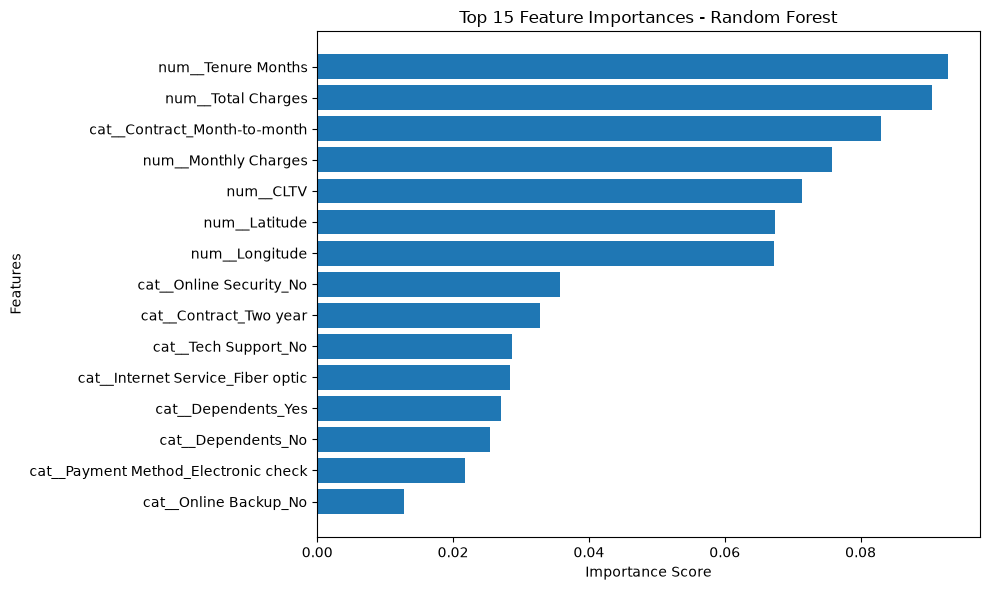

In [13]:
# Step 4: Generate Report-Quality Feature Importance Plot

top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()

plt.savefig(
    "../reports/figures/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# Cleaner Labels for Project Report

importance_df["Feature"] = (
    importance_df["Feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
)

### Swagger API Testing Screen

### Streamlit Home Page

### Prediction Dashboard

### ROC Curve

In [15]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.savefig(
    "../reports/figures/roc_curve.png",
    dpi=300
)

plt.show()

NameError: name 'y_test' is not defined

### Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.title("Confusion Matrix")

plt.savefig(
    "../reports/figures/confusion_matrix.png",
    dpi=300
)

plt.show()

### Precision-Recall Curve

In [ ]:
from sklearn.metrics import precision_recall_curve

In [ ]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.savefig(
    "../reports/figures/pr_curve.png",
    dpi=300
)

plt.show()

### Calibration Curve

In [ ]:
from sklearn.calibration import calibration_curve

In [ ]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10
)

plt.plot(prob_pred, prob_true, marker="o")

plt.plot([0,1],[0,1],'--')

plt.title("Calibration Curve")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")

plt.savefig(
    "../reports/figures/calibration_curve.png",
    dpi=300
)

plt.show()

### Model Comparison Chart

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
models = [
    "LogReg",
    "RF",
    "ExtraTrees",
    "GB",
    "HistGB",
    "AdaBoost",
    "SVC",
    "MLP",
    "XGBoost",
    "LightGBM",
    "CatBoost"
]

f1_scores = [
    0.6276,
    0.6454,
    0.5950,
    0.6323,
    0.6249,
    0.6199,
    0.6386,
    0.5664,
    0.6285,
    0.6352,
    0.6327
]

plt.figure(figsize=(10,6))

plt.bar(models, f1_scores)

plt.title("Model Comparison by F1 Score")

plt.ylabel("F1 Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/figures/model_comparison.png",
    dpi=300
)

plt.show()